In [1]:
# ============================================================
# 1) IMPORTS & CONFIG
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# ------------------------------
# CONFIG
# ------------------------------
PV_CSV_PATH = "pv_data.csv"
WEATHER_CSV_PATH = "weather_data.csv"

TARGET_COL = "pv"

EXOG_FEATURES = [
    "temperature",
    "glob_radiation_wm2",
    "sun_hours",
    "hour_sin", "hour_cos",
    "dow_sin", "dow_cos",
    "woy_sin", "woy_cos"
]

ALL_FEATURES = [TARGET_COL] + EXOG_FEATURES


In [2]:
# ============================================================
# 2) PREPROCESSING
# ============================================================

# 1) Load PV
pv_df = pd.read_csv(
    PV_CSV_PATH,
    sep=",",
    parse_dates=["timestamp"],
    index_col="timestamp"
)
pv_df = pv_df.apply(pd.to_numeric, errors="coerce")
pv_hourly = pv_df.resample("1h").mean()

# 2) Load weather
weather_df = pd.read_csv(
    WEATHER_CSV_PATH,
    sep=",",
    parse_dates=["time"],
    index_col="time"
)
if weather_df.index.tz is not None:
    weather_df.index = weather_df.index.tz_convert(None)
weather_df = weather_df.apply(pd.to_numeric, errors="coerce")
weather_df = weather_df.loc["2024-07-01":"2025-10-20"]

# 3) Merge
df = pv_hourly.join(weather_df, how="inner")

# 4) Time features
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["weekofyear"] = df.index.isocalendar().week

df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)
df["dow_sin"]  = np.sin(2*np.pi*df["dayofweek"]/7)
df["dow_cos"]  = np.cos(2*np.pi*df["dayofweek"]/7)
df["woy_sin"]  = np.sin(2*np.pi*df["weekofyear"]/52)
df["woy_cos"]  = np.cos(2*np.pi*df["weekofyear"]/52)

df = df[ALL_FEATURES]
df = df.replace(["None","nan","NaN",""], pd.NA).ffill().bfill()

# 5) Train/val/test split
split_train = int(len(df) * 0.7)
split_val   = int(len(df) * 0.85)

df_train = df.iloc[:split_train]
df_val   = df.iloc[split_train:split_val]
df_test  = df.iloc[split_val:]

# 6) Scaling
scaler_y = StandardScaler()
scaler_X = StandardScaler()

scaler_y.fit(df_train[[TARGET_COL]])
scaler_X.fit(df_train[EXOG_FEATURES])

# Apply scaling
df_scaled = df.copy()
df_scaled[TARGET_COL] = scaler_y.transform(df[[TARGET_COL]])
df_scaled[EXOG_FEATURES] = scaler_X.transform(df[EXOG_FEATURES])

# 7) Assign X/y
X_train = df_scaled[EXOG_FEATURES].iloc[:split_train]
y_train = df_scaled[TARGET_COL].iloc[:split_train]

X_val = df_scaled[EXOG_FEATURES].iloc[split_train:split_val]
y_val = df_scaled[TARGET_COL].iloc[split_train:split_val]

X_test = df_scaled[EXOG_FEATURES].iloc[split_val:]
y_test = df_scaled[TARGET_COL].iloc[split_val:]

print("Shapes:")
print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)


Shapes:
Train: (8013, 9)
Val:   (1717, 9)
Test:  (1718, 9)


Validation RMSE: 19.854000561236624
Test RMSE: 17.827425279842068


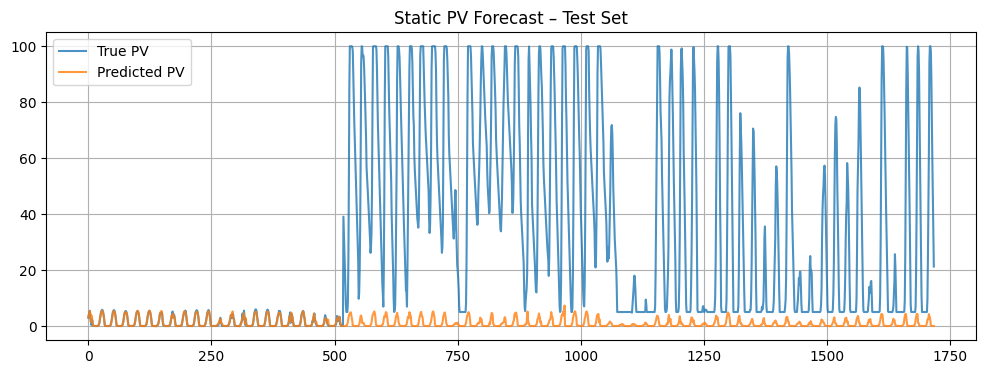

Next-step PV prediction: -0.0037063460596404862


In [3]:
# ============================================================
# 3) XGBOOST MODEL TRAINING & EVALUATION
# ============================================================

# Train model
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

# Predict
pred_val = model.predict(X_val)
pred_test = model.predict(X_test)

# RMSE function
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("Validation RMSE:", rmse(y_val, pred_val))
print("Test RMSE:", rmse(y_test, pred_test))

# Inverse scale for plotting
pred_test_inv = scaler_y.inverse_transform(pred_test.reshape(-1,1)).flatten()
y_test_inv    = scaler_y.inverse_transform(y_test.values.reshape(-1,1)).flatten()

plt.figure(figsize=(12,4))
plt.plot(y_test_inv, label="True PV", alpha=0.8)
plt.plot(pred_test_inv, label="Predicted PV", alpha=0.8)
plt.legend()
plt.grid(True)
plt.title("Static PV Forecast – Test Set")
plt.show()

# Next-step prediction
next_pred_scaled = model.predict(X_test.iloc[-1:])[0]
next_pred = scaler_y.inverse_transform([[next_pred_scaled]])[0][0]
print("Next-step PV prediction:", next_pred)
